# Gravimetry Satellites and Ocean Mass Data Products

These notes summarize the main satellite missions and product types used for observing ocean mass and ocean bottom pressure. They are intended to accompany the MS 274 gravimetry lecture and the physical-basis and algorithms notebooks.

## Motivation

Satellite gravimetry is a low-resolution but globally powerful observing system. It is especially useful when the oceanographic question involves changes in total mass, basin-scale water storage, large-scale circulation, or the mass component of sea-level rise.

### Learning Objectives

By the end of this notebook, you should be able to:

- Identify major satellite gravimetry missions relevant to oceanography.
- Distinguish static gravity-field missions from time-variable gravity missions.
- Recognize common GRACE and GRACE-FO product types.
- Choose an appropriate product for simple ocean mass or bottom pressure questions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Major Satellite Gravimetry Missions

### GOCE

GOCE, the Gravity Field and Steady State Ocean Circulation Explorer, was designed to measure Earth's static gravity field and improve estimates of the geoid. This is important for oceanography because mean dynamic topography requires separating the geoid from the sea surface height field.

### GRACE and GRACE-FO

GRACE, the Gravity Recovery and Climate Experiment, used two satellites flying in sequence to detect time-variable gravity. GRACE-FO is the follow-on mission. These missions are central to observing monthly-to-longer changes in ocean mass.

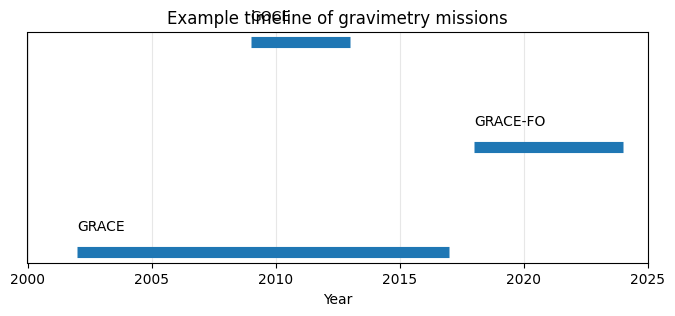

In [2]:
# Mission timeline based on the lecture slides.
missions = ['GRACE', 'GRACE-FO', 'GOCE']
starts = np.array([2002, 2018, 2009])
ends = np.array([2017, 2024, 2013])  # 2024 is only used as a plotting endpoint for the example timeline.

plt.figure(figsize=(8, 3))
for i, (mission, start, end) in enumerate(zip(missions, starts, ends)):
    plt.hlines(i, start, end, linewidth=8)
    plt.text(start, i + 0.18, mission, va='bottom')
plt.yticks([])
plt.xlabel('Year')
plt.title('Example timeline of gravimetry missions')
plt.xlim(2000, 2025)
plt.grid(True, axis='x', alpha=0.3)
plt.show()

## What the Missions Measure

| Mission type | Example | Primary measurement idea | Oceanographic relevance |
|---|---|---|---|
| Static gravity / geoid | GOCE | Gravity gradients and geoid structure | Mean dynamic topography and ocean circulation reference surfaces |
| Time-variable gravity | GRACE, GRACE-FO | Changes in inter-satellite distance caused by gravity variations | Ocean mass, bottom pressure, ice-sheet mass loss, hydrology, sea-level budget |

The key distinction is that GOCE is mainly associated with the static gravity field, while GRACE-style missions are especially useful for time-variable mass change.

## Common Product Types

### Spherical Harmonic Coefficients

These products represent the global gravity field using spherical-harmonic coefficients. They are flexible and mathematically compact, but users often need to apply filtering, corrections, and ocean/land masks.

### Mascon Products

Mascon products estimate mass changes in predefined regions. They are often more convenient for geophysical interpretation because the product is already expressed as mass or equivalent water height.

### Ocean Bottom Pressure Products

Some products are tailored to ocean applications and express anomalies as ocean bottom pressure or equivalent ocean mass.

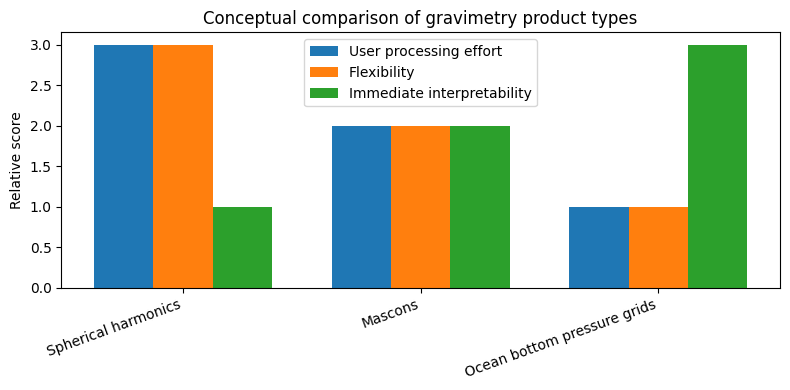

In [3]:
# Compare product families with a simple scorecard.
products = ['Spherical harmonics', 'Mascons', 'Ocean bottom pressure grids']
user_effort = np.array([3, 2, 1])
flexibility = np.array([3, 2, 1])
interpretability = np.array([1, 2, 3])

x = np.arange(len(products))
width = 0.25
plt.figure(figsize=(8, 4))
plt.bar(x - width, user_effort, width, label='User processing effort')
plt.bar(x, flexibility, width, label='Flexibility')
plt.bar(x + width, interpretability, width, label='Immediate interpretability')
plt.xticks(x, products, rotation=20, ha='right')
plt.ylabel('Relative score')
plt.title('Conceptual comparison of gravimetry product types')
plt.legend()
plt.tight_layout()
plt.show()

## Spatial and Temporal Resolution

GRACE and GRACE-FO are most useful for large-scale signals. They are not designed to observe small coastal features, mesoscale eddies, or high-frequency variability. Monthly products are common, and interpretation usually focuses on basin-scale or regional-scale mass variability.

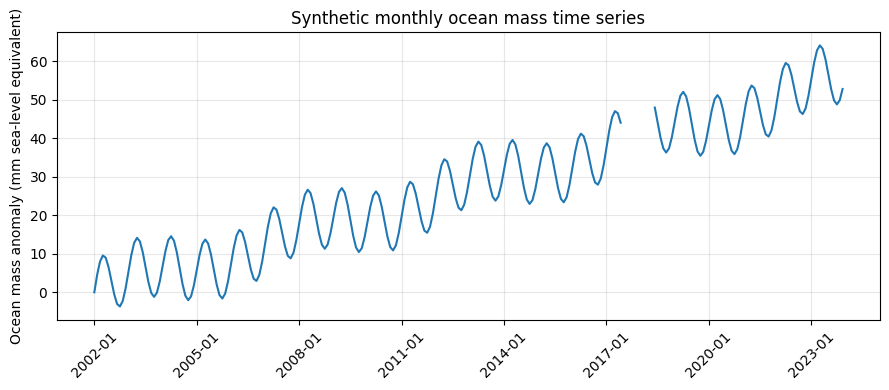

In [4]:
# Synthetic monthly ocean mass anomaly with a GRACE-to-GRACE-FO style mission gap.
months = np.arange(np.datetime64('2002-01'), np.datetime64('2024-01'), np.timedelta64(1, 'M'))
t = np.arange(len(months)) / 12
signal = 2.5*t + 8*np.sin(2*np.pi*t) + 3*np.sin(2*np.pi*t/5)

# Put a simple gap between missions for illustration.
gap = (months >= np.datetime64('2017-07')) & (months <= np.datetime64('2018-05'))
signal_gap = signal.copy()
signal_gap[gap] = np.nan

plt.figure(figsize=(9, 4))
plt.plot(months.astype('datetime64[M]').astype(str), signal_gap)
plt.xticks(np.arange(0, len(months), 36), rotation=45)
plt.ylabel('Ocean mass anomaly (mm sea-level equivalent)')
plt.title('Synthetic monthly ocean mass time series')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Applications in Oceanography

Satellite gravimetry can be used to study:

- basin-scale ocean mass variability,
- ocean bottom pressure changes,
- changes in large-scale circulation,
- the mass component of global mean sea-level rise,
- closure of the sea-level budget when combined with altimetry and in situ temperature/salinity observations,
- exchanges of water mass among ocean, land, ice, and atmosphere.

## Combining Gravimetry with Other Observations

A common sea-level budget framework is:

\begin{equation}
\text{Altimetry sea level} \approx \text{GRACE ocean mass} + \text{Argo steric sea level}
\end{equation}

Altimetry gives total sea level. GRACE gives the mass component. Argo temperature and salinity profiles help estimate the steric component. Agreement among these observing systems is an important consistency check.

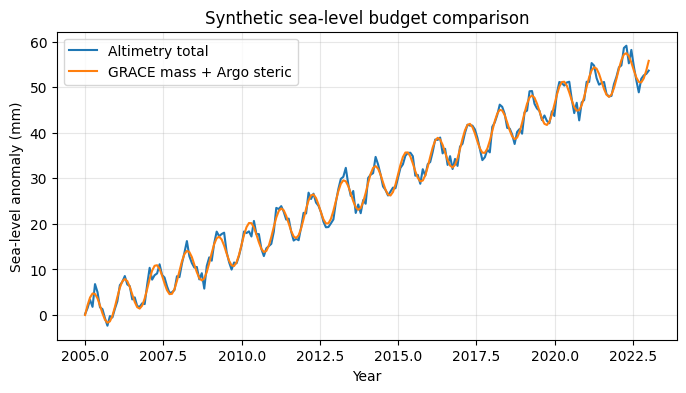

In [5]:
# Synthetic sea-level budget closure example.
years = np.linspace(2005, 2023, 19*12)
seasonal = 4*np.sin(2*np.pi*years)

grace_mass = 2.1*(years-2005) + 0.4*seasonal
argo_steric = 1.0*(years-2005) + 0.6*seasonal
altimetry = grace_mass + argo_steric + np.random.default_rng(2).normal(0, 1.2, len(years))

plt.figure(figsize=(8, 4))
plt.plot(years, altimetry, label='Altimetry total')
plt.plot(years, grace_mass + argo_steric, label='GRACE mass + Argo steric')
plt.xlabel('Year')
plt.ylabel('Sea-level anomaly (mm)')
plt.title('Synthetic sea-level budget comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Product Selection Guide

| Research question | Useful product type | Notes |
|---|---|---|
| What is the mass component of global mean sea-level rise? | Ocean-mass or mascon product | Compare with altimetry and steric estimates. |
| How does bottom pressure vary in a basin? | Ocean bottom pressure grid or mascon product | Watch for leakage near land and ice. |
| How does the geoid affect mean dynamic topography? | Static gravity/geoid product | GOCE is especially relevant. |
| Do I need custom filtering or a special region? | Spherical harmonic product | More flexible, but more processing burden. |

### Check Your Understanding

1. Why is GOCE more associated with the static gravity field, while GRACE is more associated with time-variable mass?
2. Why are monthly, basin-scale analyses more typical than daily, coastal analyses for GRACE-style data?
3. Which product would you choose for a first look at ocean bottom pressure, and why?
4. Why is it useful to combine altimetry, GRACE, and Argo in sea-level studies?

## References and Further Reading

- MS 274 Lesson 15a slides: Gravimetry.
- GRACE and GRACE-FO mission documentation from NASA/JPL and partner institutions.
- ESA GOCE mission documentation.
- Chambers, D. P., & Bonin, J. A. (2012). Evaluation of GRACE time-variable gravity coefficients over the ocean.
- Johnson, G. C., & Chambers, D. P. (2013). Ocean bottom pressure seasonal cycles and decadal trends from GRACE.